#  Task 1: Random Forest Classification

###  Intern Name: Adyasha Mohanty  
###  Intern ID: CV/A1/64922  
###  Organization: Codveda Technologies  
###  Date:10/04/2026

---

##  Objective:
To build a Random Forest model to predict customer churn and compare its performance with Logistic Regression.

##  Importing Libraries

In [ ]:
import pandas as pd
import numpy as np

##  Loading Dataset

In [ ]:
df = pd.read_csv('/content/churn-bigml-80.csv')
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


##  Data Overview

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


##  Data Cleaning

In [ ]:
# Drop unnecessary column
if 'State' in df.columns:
    df = df.drop('State', axis=1)

# Convert target
df['Churn'] = df['Churn'].map({True: 1, False: 0})

##  Encoding Categorical Variables

In [ ]:
df = pd.get_dummies(df, drop_first=True)

##  Feature Selection

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

##  Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

##  Training Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##  Model Prediction

In [ ]:
y_pred = model.predict(X_test)

##  Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.947565543071161

Confusion Matrix:
 [[454   1]
 [ 27  52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       455
           1       0.98      0.66      0.79        79

    accuracy                           0.95       534
   macro avg       0.96      0.83      0.88       534
weighted avg       0.95      0.95      0.94       534



##  Feature Importance


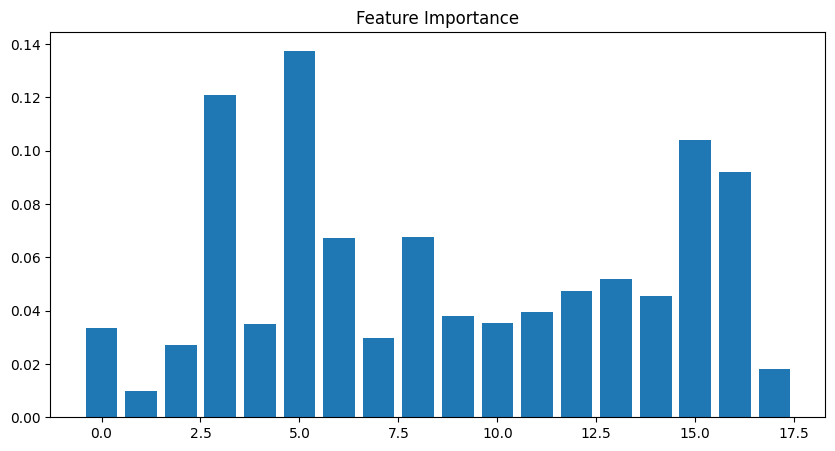

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

##  Conclusion

The Random Forest model was successfully implemented for customer churn prediction.

Compared to Logistic Regression, Random Forest provides better performance by combining multiple decision trees, reducing overfitting and improving accuracy.

Feature importance analysis helped identify the most influential factors affecting churn.

This task demonstrates the power of ensemble learning methods in machine learning.